In [2]:
from enum import Enum
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_PATH = "data/processed/intensities_t2.csv"


class T1ModelSchema(str, Enum):
	"""Enumeration of active features and target used in Tier 1 model training.

	Predictors (X):
		MAG: Preferred earthquake magnitude (Mw).
		MMI: Observed Modified Mercalli Intensity shaking threshold.
		DEPTH_S: Focal depth relative to DEM ground surface (km).
		REGIME: Tectonic regime classification (e.g., subduction, crustal).

	Target (y):
		RHYPO: 3D straight-line hypocentral distance (km).
	"""

	MAG = "magnitude"
	MMI = "mmi"
	DEPTH_S = "depth_surface"
	REGIME = "regime"
	RHYPO = "r_hypo"
	VS30 = "vs30"

ALL_FEATURES = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, 
                T1ModelSchema.DEPTH_S.value, T1ModelSchema.REGIME.value, 
				T1ModelSchema.VS30.value]
ALL_PROPERTIES = ALL_FEATURES + [T1ModelSchema.RHYPO.value]
NUMERIC_PROPERTIES = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, 
                      T1ModelSchema.VS30.value, T1ModelSchema.DEPTH_S.value, 
					  T1ModelSchema.RHYPO.value]

NUMERIC_PROPERTIES_FOR_MODEL = [
	T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, T1ModelSchema.RHYPO.value,
	T1ModelSchema.VS30.value
	]

class MetadataSchema(str, Enum):
	"""Enumeration of passive metadata and auxiliary spatial features.

	Used for GroupKFold splitting keys, spatial indexing, and coordinate references.
	These are excluded from the direct model input vector.
	"""
	ID = "usgs_id"
	LONGITUDE = "longitude"
	LATITUDE = "latitude"

In [3]:
df = pd.read_csv(DATASET_PATH)
df.shape

(546619, 9)

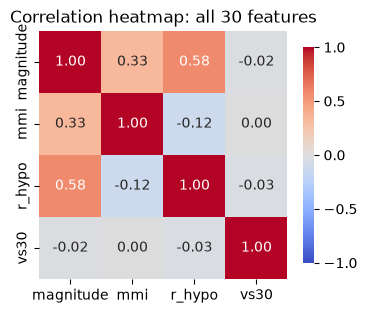

4674

In [4]:
plt.figure(figsize=(4, 4))
numeric_df = df[NUMERIC_PROPERTIES_FOR_MODEL]
numeric_labels = numeric_df.columns.tolist()

correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, xticklabels=numeric_labels, yticklabels=numeric_labels, 
			cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
			square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation heatmap: all 30 features")
plt.show()

del numeric_df, correlation_matrix
gc.collect()

In [5]:
def create_unique_splits(df: pd.DataFrame, id_col: str, frac: float = 0.75, random_state: int = 42):
	unique_ids = df[id_col].unique()
	sampled_ids = pd.Series(unique_ids).sample(frac=frac, random_state=random_state)
	return df[df[id_col].isin(sampled_ids)].copy()

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

class RegressorEvaluator:
	"""
	The RegressorEvaluator class provides a structured and reusable pipeline for evaluating multiple 
	regression models on a dataset. It manages the entire workflow, including data preparation, model 
	training, evaluation, and prediction generation.

	Each stage is implemented as a separate function, making it easy to customize preprocessing steps, 
	model selection, and evaluation metrics. These functions also return relevant outputs, allowing 
	intermediate results to be inspected, analyzed, or reused during the evaluation process.

	For a quick evaluation, simply call run(). It executes the complete pipeline and returns 
	both the evaluation results and prediction results as pandas DataFrames. Additional metrics 
	can be enabled or customized when needed.
	"""
	def __init__(self, df, target_col, split_id_col, models, 
				 pre_split_drop=None, post_split_drop=None, 
				 test_size=0.05, random_state=42,show_full_df=False):
		"""
		Initializes the evaluation pipeline.
		Args:
			df: The pre-transformed Pandas DataFrame.
			target_col: Name of the target variable column.
			split_id_col: Column to group by for GroupShuffleSplit (auto-dropped).
			models: Dictionary of instantiated sklearn models.
			pre_split_drop: List of columns to drop before splitting.
			post_split_drop: List of columns to drop after splitting.
			test_size: Proportion of groups to include in the test split.
			random_state: Seed for reproducibility.
		"""
		self.df = df.copy()
		self.target_col = target_col
		self.split_id_col = split_id_col
		self.models = models
		self.pre_split_drop = pre_split_drop or []
		self.post_split_drop = post_split_drop or []
		self.test_size = test_size
		self.random_state = random_state
		self.show_full_df = show_full_df

		# Placeholders for state
		self.train_df, self.test_df = None, None
		self.X_train, self.X_test = None, None
		self.y_train, self.y_test = None, None
		self.eval_df = None
		self.predictions_df = None

	def prepare_data(self):
		"""
		Handles dropping columns, GroupShuffleSplit, and X/y separation.
		Returns:
			X_train, X_test, y_train, y_test: Prepared training and testing datasets.
		"""
		# 1. Drop pre-split columns (ensuring we don't drop the split_id_col yet)
		drop_pre = [c for c in self.pre_split_drop if c in self.df.columns and c != self.split_id_col]
		if drop_pre:
			self.df = self.df.drop(columns=drop_pre)

		# 2. Group Shuffle Split
		gss = GroupShuffleSplit(n_splits=1, test_size=self.test_size, random_state=self.random_state)
		train_idx, test_idx = next(gss.split(self.df, groups=self.df[self.split_id_col]))

		self.train_df = self.df.iloc[train_idx].copy()
		self.test_df = self.df.iloc[test_idx].copy()

		# 3. Auto-drop the split_id column from train and test sets
		self.train_df = self.train_df.drop(columns=[self.split_id_col])
		self.test_df = self.test_df.drop(columns=[self.split_id_col])

		# 4. Drop post-split columns (if any)
		if self.post_split_drop:
			drop_post = [c for c in self.post_split_drop if c in self.train_df.columns]
			self.train_df = self.train_df.drop(columns=drop_post)
			self.test_df = self.test_df.drop(columns=drop_post)

		# 5. Separate Features (X) and Target (y)
		self.X_train = self.train_df.drop(columns=[self.target_col])
		self.y_train = self.train_df[self.target_col]
		self.X_test = self.test_df.drop(columns=[self.target_col])
		self.y_test = self.test_df[self.target_col]

		print(f"Train set shape: {self.X_train.shape}, {self.y_train.shape}")
		print(f"Test set shape: {self.X_test.shape}, {self.y_test.shape}")
		print(f"X_test columns: {self.X_test.columns.tolist()}")
		print(f"y_test columns: {self.y_test.name if hasattr(self.y_test, 'name') else 'N/A'}")

		return self.X_train, self.X_test, self.y_train, self.y_test

	def fit_and_evaluate(self):
		"""Trains models, prints coefficients, and calculates metrics."""
		eval_records = []

		for model_name, model in self.models.items():
			# Train the model
			model.fit(self.X_train, self.y_train)

			# Extract and print coefficients
			string = f"{model_name} Coefficients: "
			if hasattr(model, 'coef_'):
				string += str(model.coef_)
			else:
				string += "N/A"
			if hasattr(model, 'intercept_'):
				string += f", Intercept: {model.intercept_}"
			print(string)

			# Evaluate
			pred = model.predict(self.X_test)
			train_score = model.score(self.X_train, self.y_train)
			test_score = model.score(self.X_test, self.y_test)
			
			eval_records.append({
				"model": model_name,
				"train_score": train_score,
				"test_score": test_score,
				"r2_score": r2_score(self.y_test, pred),
				"mse": mean_squared_error(self.y_test, pred),
				"mae": mean_absolute_error(self.y_test, pred),
			})

		# Using list of dicts instead of pd.concat inside a loop (much faster)
		self.eval_df = pd.DataFrame(eval_records)
		return self.eval_df

	def generate_predictions(self):
		"""Appends model predictions to the test dataframe."""
		if self.test_df is None or self.X_test is None:
			raise ValueError("Data not prepared. Call prepare_data() before generating predictions.")
		if self.show_full_df:
			self.predictions_df = self.test_df.copy()
		else:
			self.predictions_df = self.test_df[[self.target_col]].copy()
		
		for model_name, model in self.models.items():
			self.predictions_df[f"{model_name}_pred"] = model.predict(self.X_test)

		return self.predictions_df

	def run(self):
		"""Executes the entire pipeline and returns evaluation and prediction DFs."""
		self.prepare_data()
		print("-" * 50)
		self.fit_and_evaluate()
		self.generate_predictions()
		
		return self.eval_df, self.predictions_df

In [7]:
from sklearn.linear_model import (
	LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)


def create_models() -> dict:
	"""Creates a dictionary of regression models."""
	return{
		"LinearRegression": LinearRegression(),
		"Ridge": Ridge(alpha=1.0),
		"Lasso": Lasso(alpha=0.1),
		"ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
		"BayesianRidge": BayesianRidge(),
		"HuberRegressor":HuberRegressor( max_iter=1000, alpha=0.0001)
	}


In [ ]:


# formula: M~ a + b*Mag + c*MMi+d*log(MMI+1)+ e*log(Depth+1)+ f*log(Vs30/760)+

df_sample = df.sample(frac =1.0, random_state=100)
active_df = df_sample[df_sample[T1ModelSchema.REGIME.value] == "active"].copy()

target = T1ModelSchema.RHYPO.value
active_df[target] = np.log10(active_df[target] + 1)

id_col = MetadataSchema.ID.value
pre_drop = [f.value for f in MetadataSchema if f != id_col] + [T1ModelSchema.REGIME.value]


# standardize vs30 by dividing by 760 and applying log10 transformation
active_df[T1ModelSchema.VS30.value] = np.log10(active_df[T1ModelSchema.VS30.value]/760)


models = create_models()

evaluator = RegressorEvaluator(
    df=active_df,
    target_col=target,
    split_id_col=id_col,
    models=models,
    pre_split_drop=pre_drop,
    post_split_drop=[], 
    test_size=0.2,
    random_state=2
)

evaluation_metrics, test_predictions = evaluator.run()

print(evaluation_metrics)

tp = test_predictions.copy()

tp[target] = np.round(np.exp(tp[target]) - 1, 3)
pred_cols = [c for c in tp.columns if c.endswith("_pred")]
for col in pred_cols:
    tp[col] = np.round(np.exp(tp[col]) - 1, 3)

display(tp)

del evaluator, active_df, df_sample, models, pre_drop, id_col, target
gc.collect()

Train set shape: (419982, 4), (419982,)
Test set shape: (99288, 4), (99288,)
X_test columns: ['magnitude', 'mmi', 'vs30', 'depth_surface']
y_test columns: r_hypo
--------------------------------------------------
LinearRegression Coefficients: [ 0.71475053 -0.38789058  0.04894846  0.00962901], Intercept: 1.916745603177326
Ridge Coefficients: [ 0.71474821 -0.38788872  0.04894728  0.009629  ], Intercept: 1.9167495883524777
Lasso Coefficients: [ 0.56120785 -0.21748646  0.          0.00178586], Intercept: 2.1431196243722095
ElasticNet Coefficients: [ 0.59827809 -0.27313157  0.          0.00565612], Intercept: 2.101024102848127
BayesianRidge Coefficients: [ 0.71474506 -0.38788618  0.04894569  0.00962899], Intercept: 1.9167550189973328
HuberRegressor Coefficients: [ 0.75805012 -0.40739192  0.08481279  0.01243301], Intercept: 1.7407533516907585
              model  train_score  test_score  r2_score       mse       mae
0  LinearRegression     0.544633    0.516008  0.516008  0.427035  0.502633


,r_hypo,LinearRegression_pred,Ridge_pred,Lasso_pred,ElasticNet_pred,BayesianRidge_pred,HuberRegressor_pred
188797,164.332,209.219,209.218,181.726,184.560,209.217,215.349
167392,116.630,36.663,36.663,45.426,42.480,36.663,33.944
534500,7.157,23.921,23.921,31.420,28.787,23.922,21.601
224713,254.454,260.832,260.831,202.717,211.713,260.829,276.262
1620,7.524,34.634,34.634,41.369,38.922,34.634,31.894
...,...,...,...,...,...,...,...
442370,25.411,19.124,19.124,25.431,23.432,19.124,17.502
96305,53.742,54.969,54.969,54.948,54.536,54.969,52.470
254980,212.861,87.773,87.772,69.600,74.953,87.772,84.579
173563,129.873,341.124,341.122,236.216,256.530,341.120,365.177


25

In [ ]:
# formula: M~ a + b*Mag + c*MMi + d*log(MMI+1) + e*log(Depth+1) + f*log(Vs30/760)

df_sample = df.sample(frac=0.75, random_state=100)



active_df = df_sample[df_sample[T1ModelSchema.REGIME.value] == "active"].copy()

target = T1ModelSchema.RHYPO.value
active_df[target] = np.log10(active_df[target])

# Feature engineering matching the formula terms
active_df["mmi_log"] = np.log10(active_df[T1ModelSchema.MMI.value] + 1)
active_df["depth_log"] = np.log10(active_df[T1ModelSchema.DEPTH_S.value] + 1)
active_df["vs30_log"] = np.log10(active_df[T1ModelSchema.VS30.value] / 760.0)

id_col = MetadataSchema.ID.value
pre_drop = [f.value for f in MetadataSchema if f != id_col] + [
    T1ModelSchema.VS30.value,  # Drop raw Vs30 in favor of log(Vs30/760)
    T1ModelSchema.REGIME.value,  # Drop regime as it's not a direct predictor
    T1ModelSchema.DEPTH_S.value,  # Drop raw 
]

models = create_models()

evaluator = RegressorEvaluator(
    df=active_df,
    target_col=target,
    split_id_col=id_col,
    models=models,
    pre_split_drop=pre_drop,
    post_split_drop=[], 
    test_size=0.2,
    random_state=2
)

evaluation_metrics, test_predictions = evaluator.run()

print(evaluation_metrics)

tp = test_predictions.copy()

tp[target] = np.round(np.exp(tp[target]) - 1, 3)
pred_cols = [c for c in tp.columns if c.endswith("_pred")]
for col in pred_cols:
    tp[col] = np.round(np.exp(tp[col]) - 1, 3)

display(tp)

del evaluator, active_df, df_sample, models, pre_drop, id_col, target
gc.collect()

Train set shape: (317364, 5), (317364,)
Test set shape: (72243, 5), (72243,)
X_test columns: ['magnitude', 'mmi', 'mmi_log', 'depth_log', 'vs30_log']
y_test columns: r_hypo
--------------------------------------------------
LinearRegression Coefficients: [ 0.68250115 -0.52130272  0.54944279  0.11879026  0.03340117], Intercept: 1.5156941715222603
Ridge Coefficients: [ 0.68249283 -0.52109665  0.54861263  0.11878666  0.03340431], Intercept: 1.5162488722443164
Lasso Coefficients: [ 0.52937758 -0.21605968 -0.          0.          0.        ], Intercept: 2.290269770413378
ElasticNet Coefficients: [ 0.5684095  -0.26977662 -0.          0.          0.        ], Intercept: 2.2742438936656657
BayesianRidge Coefficients: [ 0.68248528 -0.52090981  0.54785994  0.1187834   0.03340716], Intercept: 1.516751829088851
HuberRegressor Coefficients: [ 0.72505635 -0.56264582  0.63663662  0.15399387  0.06789685], Intercept: 1.2381694824431386
              model  train_score  test_score  r2_score       mse   

,r_hypo,LinearRegression_pred,Ridge_pred,Lasso_pred,ElasticNet_pred,BayesianRidge_pred,HuberRegressor_pred
480485,16.090,36.559,36.559,38.916,38.319,36.558,34.645
534500,7.157,24.166,24.166,32.212,30.195,24.165,21.809
529010,12.285,22.551,22.551,27.097,25.565,22.551,20.831
196284,175.493,159.330,159.325,130.481,135.168,159.320,165.675
332762,74.078,25.154,25.154,33.358,31.969,25.154,22.269
...,...,...,...,...,...,...,...
97506,54.214,62.301,62.300,56.590,57.946,62.299,60.046
70567,40.648,54.288,54.287,52.552,51.697,54.286,53.274
15927,18.273,30.106,30.106,36.069,33.706,30.106,28.321
365403,52.620,81.934,81.934,65.553,68.900,81.935,81.650


0

In [10]:
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor

def create_models_2():
    return {
        "LinearRegression": LinearRegression(),
        "HuberRegressor": HuberRegressor(max_iter=1000),
        
        # 1. LightGBM (Highly recommended for speed and non-linear interactions)
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=100, 
            learning_rate=0.05, 
            random_state=42,
            verbose=-1
        ),
        
        # 2. Random Forest (Great for robust spatial/geological splits)
        "RandomForest": RandomForestRegressor(
            n_estimators=100, 
            max_depth=10, 
            random_state=42, 
            n_jobs=-1
        )
    }
